Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 4/10: Расчёт размера выборки. Валидация результатов → Урок 4/4: Проверка данных. Расчёт метрик по результатам эксперимента]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/81eacf80-faae-4643-a807-a9308ec382eb/lessons/65d5d1be-9c43-406f-b21d-1422a991f5dd/#6f254c5f-1744-4e16-ab10-5dfedbc7f01b )


In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('sessions_test.csv')

# Первичный анализ
df.info()
df.head()

# Преобразование типов
df['session_start_ts'] = pd.to_datetime(df['session_start_ts'])
df['session_date'] = pd.to_datetime(df['session_date']).dt.date
df['install_date'] = pd.to_datetime(df['install_date']).dt.date

# Удаление строк без названия теста
df = df[~df['test_name'].isna()].reset_index(drop=True)

# Удаление полных дублей
df = df.drop_duplicates().reset_index(drop=True)

# Проверка дубликатов по session_id
dup_session_ids = df[df.duplicated(subset=['session_id'])]['session_id'].tolist()
print("Доля дублирующихся session_id:", 100 * len(dup_session_ids) / df['session_id'].nunique(), "%")

# Проверка дубликатов по user_id + session_id
dup_user_ids = df[df.duplicated(subset=['user_id', 'session_id'])]['user_id'].tolist()
print("Доля пользователей с дублирующимися сессиями:", 100 * len(dup_user_ids) / df['user_id'].nunique(), "%")

# Оставляем последнюю запись по каждой session_id
df = df.sort_values(by=['session_id', 'page_counter']).drop_duplicates(subset=['session_id'], keep='last', ignore_index=True)

# Проверка
print("Дубликатов по session_id + page_counter:", df.duplicated(subset=['session_id', 'page_counter']).sum())

# Гистограмма page_counter (сырые данные)
plt.figure(figsize=(7, 3))
df['page_counter'].plot(kind='hist', bins=30, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()

# Удаление выбросов (по 99 перцентилю)
cleaned_page_counter = df[df['page_counter'] <= df['page_counter'].quantile(0.99)]['page_counter']

# Гистограмма без выбросов
plt.figure(figsize=(7, 3))
cleaned_page_counter.plot(kind='hist', bins=6, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию (без выбросов)')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()

# Обновляем колонку page_counter без выбросов
df['page_counter'] = df['page_counter'].where(
    df['page_counter'] <= df['page_counter'].quantile(0.99)
)

# Проверка групп
print(df['test_group'].unique())
print(
    df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique(),
    df[df['test_group'] == 'MENA_English']['user_id'].nunique()
)
print(
    100 * df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique() / df['user_id'].nunique(),
    100 * df[df['test_group'] == 'MENA_English']['user_id'].nunique() / df['user_id'].nunique()
)

# Проверка пересечения пользователей между группами
arabian = df[df['test_group'] == 'MENA_Arabian']['user_id']
english = df[df['test_group'] == 'MENA_English']['user_id']
intersection = list(set(arabian) & set(english))
print("Пользователи в обеих группах:", intersection)

# Исключаем этих пользователей
df = df[~df['user_id'].isin(intersection)]

# Агрегируем по пользователю
df_users = df.groupby(['user_id', 'test_group'], as_index=False).agg({'page_counter': 'sum'})

# Метрики (среднее количество страниц по группам)
metrics = df_users.groupby('test_group')['page_counter'].mean().to_frame().T
print(metrics)

In [ ]:
# Пошагово СВМ
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('sessions_test.csv')

# Первичный анализ
df.info()
df.head()

# Преобразование типов
df['session_start_ts'] = pd.to_datetime(df['session_start_ts'])
df['session_date'] = pd.to_datetime(df['session_date']).dt.date
df['install_date'] = pd.to_datetime(df['install_date']).dt.date

# Удаление строк без названия теста
df = df[~df['test_name'].isna()].reset_index(drop=True)

# Удаление полных дублей
df = df.drop_duplicates().reset_index(drop=True)

# Проверка дубликатов по session_id
dup_session_ids = df[df.duplicated(subset=['session_id'])]['session_id'].tolist()
print("Доля дублирующихся session_id:", 100 * len(dup_session_ids) / df['session_id'].nunique(), "%")

# Проверка дубликатов по user_id + session_id
dup_user_ids = df[df.duplicated(subset=['user_id', 'session_id'])]['user_id'].tolist()
print("Доля пользователей с дублирующимися сессиями:", 100 * len(dup_user_ids) / df['user_id'].nunique(), "%")

# Оставляем последнюю запись по каждой session_id
df = df.sort_values(by=['session_id', 'page_counter']).drop_duplicates(subset=['session_id'], keep='last', ignore_index=True)

# Проверка
print("Дубликатов по session_id + page_counter:", df.duplicated(subset=['session_id', 'page_counter']).sum())

# Гистограмма page_counter (сырые данные)
plt.figure(figsize=(7, 3))
df['page_counter'].plot(kind='hist', bins=30, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()

# Удаление выбросов (по 99 перцентилю)
cleaned_page_counter = df[df['page_counter'] <= df['page_counter'].quantile(0.99)]['page_counter']

# Гистограмма без выбросов
plt.figure(figsize=(7, 3))
cleaned_page_counter.plot(kind='hist', bins=6, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию (без выбросов)')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()

# Обновляем колонку page_counter без выбросов
df['page_counter'] = df['page_counter'].where(
    df['page_counter'] <= df['page_counter'].quantile(0.99)
)

# Проверка групп
print(df['test_group'].unique())
print(
    df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique(),
    df[df['test_group'] == 'MENA_English']['user_id'].nunique()
)
print(
    100 * df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique() / df['user_id'].nunique(),
    100 * df[df['test_group'] == 'MENA_English']['user_id'].nunique() / df['user_id'].nunique()
)

# Проверка пересечения пользователей между группами
arabian = df[df['test_group'] == 'MENA_Arabian']['user_id']
english = df[df['test_group'] == 'MENA_English']['user_id']
intersection = list(set(arabian) & set(english))
print("Пользователи в обеих группах:", intersection)

# Исключаем этих пользователей
df = df[~df['user_id'].isin(intersection)]

# Агрегируем по пользователю
df_users = df.groupby(['user_id', 'test_group'], as_index=False).agg({'page_counter': 'sum'})

# Метрики (среднее количество страниц по группам)
metrics = df_users.groupby('test_group')['page_counter'].mean().to_frame().T
print(metrics)

In [1]:
# Пошагово СВМ _ 1
# Импорт библиотек
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
# ИИ посоветовал добавить этот параметр low_memory=False, чтобы избежать данной ошибки. Она возникает, 
# для столбца test_name когда python частями считывает файл и пытается определить тип данных колонки. При считывании частями тип определить непросто
# поэтому указываем считывать СРАЗУ весь файл...
df = pd.read_csv('sessions_test.csv', low_memory=False) 

# Первичный анализ
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392991 entries, 0 to 392990
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            392991 non-null  object
 1   session_id         392991 non-null  object
 2   session_date       392991 non-null  object
 3   session_start_ts   392991 non-null  object
 4   install_date       392991 non-null  object
 5   session_number     392991 non-null  int64 
 6   registration_flag  392991 non-null  int64 
 7   page_counter       392991 non-null  int64 
 8   region             392991 non-null  object
 9   device             392991 non-null  object
 10  test_name          32089 non-null   object
 11  test_group         392991 non-null  object
dtypes: int64(3), object(9)
memory usage: 36.0+ MB


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_name,test_group
0,E302123B7000BFE4,91AF1F48F760FB95,1/20/25,1/20/25 17:31,1/20/25,1,0,3,EU,Android,NaN,control
1,2530F72E221829FB,80C7C0E99656F847,1/20/25,1/20/25 17:12,1/20/25,1,0,3,CIS,iPhone,NaN,control
2,876E020A4FC512F5,DEFF44453E33527B,1/20/25,1/20/25 17:02,1/20/25,1,0,2,CIS,iPhone,NaN,control
3,2640B349E1D81584,72C6B39E8ED408BA,1/20/25,1/20/25 17:13,1/20/25,1,1,2,CIS,PC,NaN,control
4,94E1CBFAEF1F5EE9,66F015B6E0F2363F,1/20/25,1/20/25 15:09,1/20/25,1,0,4,EU,iPhone,NaN,control


In [2]:
# Пошагово СВМ _ 2
# Преобразование типов
df['session_start_ts'] = pd.to_datetime(df['session_start_ts'])
df['session_date'] = pd.to_datetime(df['session_date']).dt.date
df['install_date'] = pd.to_datetime(df['install_date']).dt.date
df[['session_date','session_start_ts','install_date']].head()


C:\Users\Sergey\AppData\Local\Temp\ipykernel_9104\4212502326.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['session_start_ts'] = pd.to_datetime(df['session_start_ts'])
C:\Users\Sergey\AppData\Local\Temp\ipykernel_9104\4212502326.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['session_date'] = pd.to_datetime(df['session_date']).dt.date
C:\Users\Sergey\AppData\Local\Temp\ipykernel_9104\4212502326.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['install_date'] = pd.to_datetime(df['install_date']).dt.date


,session_date,session_start_ts,install_date
0,2025-01-20,2025-01-20 17:31:00,2025-01-20
1,2025-01-20,2025-01-20 17:12:00,2025-01-20
2,2025-01-20,2025-01-20 17:02:00,2025-01-20
3,2025-01-20,2025-01-20 17:13:00,2025-01-20
4,2025-01-20,2025-01-20 15:09:00,2025-01-20


In [3]:
# Пошагово СВМ _ 3

# Удаление строк без названия теста
df = df[~df['test_name'].isna()].reset_index(drop=True)

# Удаление полных дублей
df = df.drop_duplicates().reset_index(drop=True)

# Проверка дубликатов по session_id
dup_session_ids = df[df.duplicated(subset=['session_id'])]['session_id'].tolist()
print("Доля дублирующихся session_id:", 100 * len(dup_session_ids) / df['session_id'].nunique(), "%")

# Проверка дубликатов по user_id + session_id
dup_user_ids = df[df.duplicated(subset=['user_id', 'session_id'])]['user_id'].tolist()
print("Доля пользователей с дублирующимися сессиями:", 100 * len(dup_user_ids) / df['user_id'].nunique(), "%")

# Оставляем последнюю запись по каждой session_id
df = df.sort_values(by=['session_id', 'page_counter']).drop_duplicates(subset=['session_id'], keep='last', ignore_index=True)

# Проверка
print("Дубликатов по session_id + page_counter:", df.duplicated(subset=['session_id', 'page_counter']).sum())


Доля дублирующихся session_id: 2.8595345722417544 %
Доля пользователей с дублирующимися сессиями: 9.38564677437081 %
Дубликатов по session_id + page_counter: 0


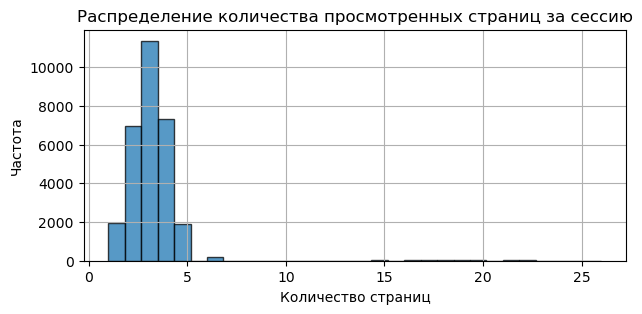

In [4]:
# Пошагово СВМ _ 4
# Гистограмма page_counter (сырые данные)
plt.figure(figsize=(7, 3))
df['page_counter'].plot(kind='hist', bins=30, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()

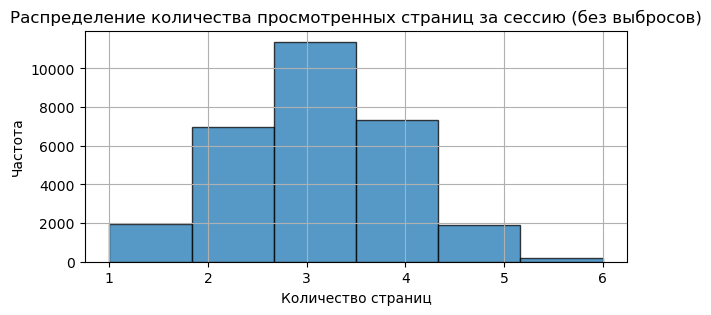

In [5]:
# Пошагово СВМ _ 5
# Удаление выбросов (по 99 перцентилю)
cleaned_page_counter = df[df['page_counter'] <= df['page_counter'].quantile(0.99)]['page_counter']

# Гистограмма без выбросов
plt.figure(figsize=(7, 3))
cleaned_page_counter.plot(kind='hist', bins=6, alpha=0.75, edgecolor='black')
plt.title('Распределение количества просмотренных страниц за сессию (без выбросов)')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
plt.grid()
plt.show()


In [ ]:
print(df['test_group'].unique())
df.groupby('test_group')['test_group'].value_counts()

In [6]:
# Пошагово СВМ _ 6
# Обновляем колонку page_counter без выбросов
df['page_counter'] = df['page_counter'].where(
    df['page_counter'] <= df['page_counter'].quantile(0.99)
)

# Проверка групп
print(df['test_group'].unique())
print(
    df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique(),
    df[df['test_group'] == 'MENA_English']['user_id'].nunique()
)
print(
    100 * df[df['test_group'] == 'MENA_Arabian']['user_id'].nunique() / df['user_id'].nunique(),
    100 * df[df['test_group'] == 'MENA_English']['user_id'].nunique() / df['user_id'].nunique()
)

# Проверка пересечения пользователей между группами
arabian = df[df['test_group'] == 'MENA_Arabian']['user_id']
english = df[df['test_group'] == 'MENA_English']['user_id']
intersection = list(set(arabian) & set(english))
print("Пользователи в обеих группах:", intersection)


['MENA_Arabian' 'MENA_English']
4401 4701
48.367952522255194 51.66501813386086
Пользователи в обеих группах: ['4BE8D1A07FB8F18F', '8C0045C86556C5B9', '632F7D20CB68A549']


In [7]:
# Пошагово СВМ _ 7
# Исключаем этих пользователей
df = df[~df['user_id'].isin(intersection)]

# Агрегируем по пользователю
df_users = df.groupby(['user_id', 'test_group'], as_index=False).agg({'page_counter': 'sum'})
print(df_users.groupby('test_group')['page_counter'].mean().head()) # СВМ
# Метрики (среднее количество страниц по группам)
metrics = df_users.groupby('test_group')['page_counter'].mean().to_frame().T # СВМ Вот это оператор трансформации Т
print(metrics)

test_group
MENA_Arabian    9.933606
MENA_English    9.828863
Name: page_counter, dtype: float64
test_group    MENA_Arabian  MENA_English
page_counter      9.933606      9.828863


In [9]:
# Эту строчку удалить
df['session_number'] = df['session_number'].astype('int64')
#session_number     392991 non-null  int64
df['session_number'].dtypes

dtype('int64')

In [17]:
# Эту ячейку можно удалить
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'user_id': [i for i in range(0, 4000, 1)],
    'check': [int(i) for i in np.random.normal(loc=900, scale=100, size=4000)]
})
df['group_name'] = 'group B'
df.loc[df.user_id % 2 == 1, 'group_name'] = 'group A'

In [18]:
from scipy.stats import ttest_ind

# Выборка средних заказов для группы А
sample_a = df[df['group_name']=='group A']['check']
# Выборка средних заказов для группы B
sample_b = df[df['group_name']=='group B']['check']

test_result = ttest_ind(
    sample_a,
    sample_b,
    alternative='less' # Альтернативная гипотеза, которую проверяем: mu_a < mu_b
)

# Фиксируем уровень значимости
alpha = 0.05

if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue={test_result.pvalue} < {alpha}')
    print('Отвергаем нулевую гипотезу')

pvalue=0.3523093690343299 > 0.05
Не получилось отвергнуть нулевую гипотезу


Однако этот этап часто оказывается избыточным, поскольку существует модификация t-теста — t-тест Уэлча, который не требует равенства дисперсий. Он применим даже в случаях, когда дисперсии в группах A и B статистически различаются, и позволяет работать с неоднородными выборками. Поэтому в качестве стандартного подхода рекомендуется использовать именно t-тест Уэлча.
Ссылки на документации в пакете `scipy` в Python (тесты на равенство выборочных дисперсий)

F-test
Bartlett-test
Levene-test

Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 5/10: Проверка результатов A/B-теста. Тест Манна-Уитни. Z-тест пропорций → Урок 2/4: T-тест и t-тест Уэлча]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/612a56cf-f700-4203-9fce-92f5a50595b3/lessons/3549f478-0da9-4233-9283-f8d98cd411cf/#3be01a93-de16-480a-98fa-7f8a671bee30 )
Вопрос: 

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\2486433853.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') ## загружаем данные в Pandas


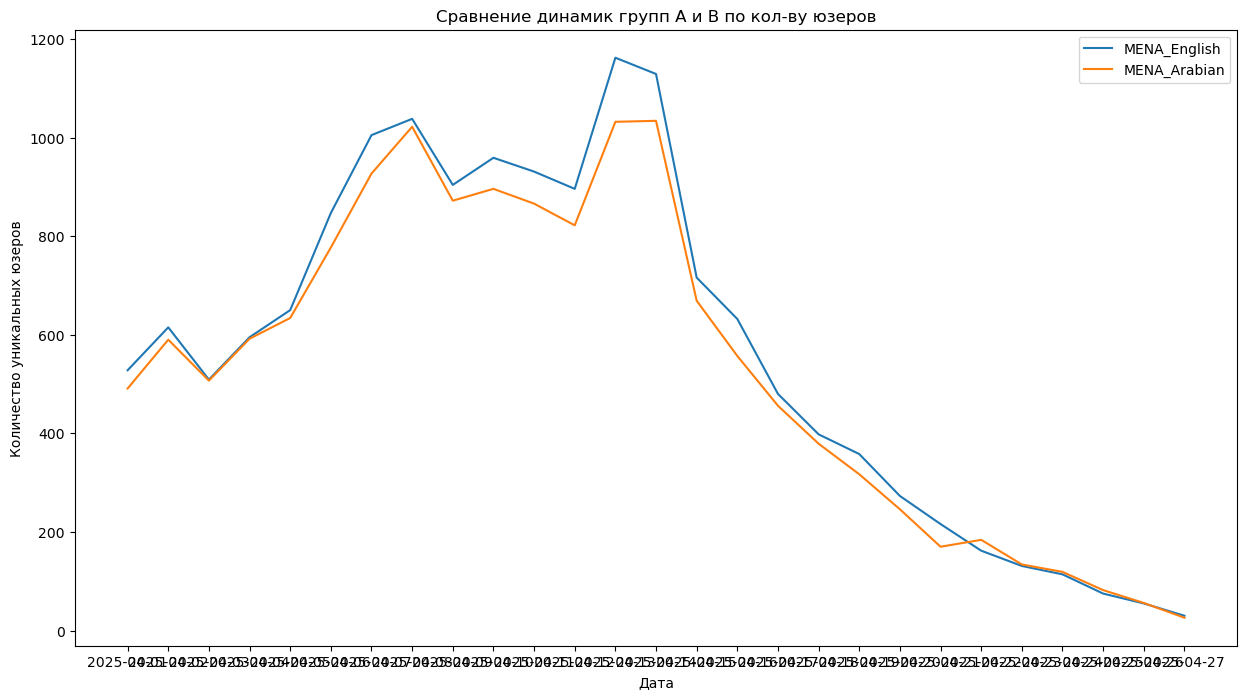

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') ## загружаем данные в Pandas

df_exp = df[
    (
        df.session_date>='2025-04-01' # начиная с 1 апреля 
    )&(
        df.session_date<'2025-04-28' # до 27 апреля (строго до 28 апреля)
    )&(
        df.test_name=='language_test'
    )
]

df_grp = (
    df_exp
    .groupby(['test_group', 'session_date'])
    .agg({
        'user_id': 'nunique',
    })
    .reset_index()
)

x = df_grp.session_date.unique()
y_a = df_grp[df_grp.test_group=='MENA_English'].user_id
y_b = df_grp[df_grp.test_group=='MENA_Arabian'].user_id

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='MENA_English')
plt.plot(x, y_b,label ='MENA_Arabian')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных юзеров")
plt.legend()
plt.title('Сравнение динамик групп A и B по кол-ву юзеров')
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Загружаем данные в pandas
df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') 

# Фильтрация данных: создаём подвыборку, соответствующую условиям эксперимента
df_exp = df[
    (
        df.session_date>='2025-04-01' # начиная с 1 апреля 
    )&(
        df.session_date<'2025-04-28' # до 27 апреля (строго до 28 апреля)
    )&(
        df.test_name=='language_test'
    )
]

# Разделение на группы: создаём две отдельные выборки для контрольной (A) и экспериментальной (B) групп
metric_a = df_exp[df_exp.test_group=='MENA_English']['page_counter'] # выборка целевой метрики для группы A
metric_b = df_exp[df_exp.test_group=='MENA_Arabian']['page_counter'] # выборка целевой метрики для группы B

# На каком уровне значимости проверяем гипотезу о равенстве выборочных средних
alpha = 0.05 

# Поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки (metric_a) меньше второй выборки, применяем тест Стьюдента (классический t-тест)
stat_ttest, p_value_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    alternative='less'
) 

if p_value_ttest>alpha:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии')
else:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны, и в группе B больше')
    print('Интерпретация: перевод интерфейса маркетплейса увеличил количество просматриваемых страниц в рамках сессии')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\1678721746.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')


p-value теста Стьюдента =1.0
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии


In [22]:
# Добавлен параметр equal_var=False: дисперсии не равны
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01' # начиная с 1 апреля 
    )&(
        df.session_date<'2025-04-28' # до 27 апреля (строго до 28 апреля)
    )&(
        df.test_name=='language_test'
    )
]

metric_a = df_exp[df_exp.test_group=='MENA_English']['page_counter'] # Выборка целевой метрики для группы A
metric_b = df_exp[df_exp.test_group=='MENA_Arabian']['page_counter'] # Выборка целевой метрики для группы B

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    equal_var=False,
    alternative='less' # Поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки(metric_a) меньше второй выборки,
) # применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны, и в группе B больше')
    print('Интерпретация: перевод интерфейса маркетплейса увеличил количество просматриваемых страниц в рамках сессии')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\4020614056.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


p-value теста Уэлча =1.0
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: перевод интерфейса маркетплейса не увеличил количество просматриваемых страниц в рамках сессии


In [27]:
df[df['device']=='Mac'].head(15)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_name,test_group
15,A75FF42475CA4E1B,CABA883A2831543B,2025-01-20,2025-01-20 19:47:06,2025-01-20,1.0,0.0,3.0,CIS,Mac,NaN,NaN
28,4C6646AD0B6700BE,006C8400ADECBEDE,2025-01-20,2025-01-20 22:50:55,2025-01-20,1.0,0.0,2.0,CIS,Mac,NaN,NaN
30,7CD61DC3D552B572,57471B88C1E604A7,2025-01-20,2025-01-20 16:13:57,2025-01-20,1.0,0.0,3.0,EU,Mac,NaN,NaN
46,FB30264AC8D9BE72,9AD9464D595654BD,2025-01-20,2025-01-20 20:47:30,2025-01-20,1.0,0.0,6.0,MENA,Mac,NaN,NaN
55,8D9E8821FAE31716,EA5A8B8240D6CBCF,2025-01-20,2025-01-20 23:19:25,2025-01-20,1.0,0.0,3.0,MENA,Mac,NaN,NaN
60,5664730986419CAE,E6BE6308C37DBBEB,2025-01-20,2025-01-20 17:19:52,2025-01-20,1.0,0.0,1.0,CIS,Mac,NaN,NaN
92,95900E2462F0FEDA,EA8A852308C5FC47,2025-01-20,2025-01-20 17:20:55,2025-01-20,1.0,0.0,2.0,CIS,Mac,NaN,NaN
106,1EAB08D1894F4033,3F91C9E8C7D50D6E,2025-01-20,2025-01-20 14:03:26,2025-01-20,1.0,0.0,4.0,EU,Mac,NaN,NaN
117,F1A5144571CEFE03,D722AE717E6E9875,2025-01-20,2025-01-20 18:18:11,2025-01-20,1.0,0.0,2.0,EU,Mac,NaN,NaN
119,9D59B51C866BCB48,6CEEB5A49E4BCF9E,2025-01-20,2025-01-20 18:51:10,2025-01-20,1.0,0.0,2.0,MENA,Mac,NaN,NaN


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392999 entries, 0 to 392998
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            392999 non-null  object 
 1   session_id         392991 non-null  object 
 2   session_date       392991 non-null  object 
 3   session_start_ts   392991 non-null  object 
 4   install_date       392991 non-null  object 
 5   session_number     392991 non-null  float64
 6   registration_flag  392991 non-null  float64
 7   page_counter       392991 non-null  float64
 8   region             392991 non-null  object 
 9   device             392991 non-null  object 
 10  test_name          32089 non-null   object 
 11  test_group         32089 non-null   object 
dtypes: float64(3), object(9)
memory usage: 36.0+ MB


In [32]:
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]

metric_a = df_exp[ # Сформируйте целевую метрику для группы A 
    (
        df_exp.test_group == 'MENA_English'
    )&(
        df_exp.device == 'Mac'
    )&(
        df_exp.registration_flag == 0.
    )
]['page_counter']
metric_b = df_exp[ # Сформируйте целевую метрику для группы B
    (
        df_exp.test_group == 'MENA_Arabian'
    )&(
        df_exp.device == 'Mac'
    )&(
        df_exp.registration_flag == 0.
    )
]['page_counter']
print(len(metric_a), len(metric_b))
print(metric_a.mean())
print(metric_b.mean())
alpha = 0.05# Зафиксируйте уровень значимости

stat_ttest, p_value_ttest = ttest_ind( # Проведите t-тест Стьюдента
	metric_a, 
    metric_b, 
    alternative='greater'
)

print(f'pvalue={round(p_value_ttest,5)}') # Выведите полученное p-value 

if p_value_ttest>alpha:  # Напишите условие, на основе которого выбирается наиболее вероятная гипотеза
    print('Нулевая гипотеза находит подтверждение!')
    text_interpretation = 'увеличилось' # Напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")
else:
    print('Нулевая гипотеза не находит подтверждения!')
    text_interpretation = 'сократилось' # Напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")



print(f'При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у незарегистрированных mac-пользователей {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\950307448.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


1536 1440
3.3020833333333335
3.0166666666666666
pvalue=0.0
Нулевая гипотеза не находит подтверждения!
При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у незарегистрированных mac-пользователей сократилось


Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 5/10: Проверка результатов A/B-теста. Тест Манна-Уитни. Z-тест пропорций → Урок 2/4: T-тест и t-тест Уэлча]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/612a56cf-f700-4203-9fce-92f5a50595b3/lessons/3549f478-0da9-4233-9283-f8d98cd411cf/#e31780ef-ac07-4fa5-9eff-9ab1ff3a9956 )
Задачи: 

In [33]:
# Образцовое решение
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]

metric_a = df_exp[
    (df_exp.test_group=='MENA_English')&(df_exp.device=='Mac')&(df_exp.registration_flag==0)
]['page_counter']
metric_b = df_exp[
    (df_exp.test_group=='MENA_Arabian')&(df_exp.device=='Mac')&(df_exp.registration_flag==0)
]['page_counter']

alpha = 0.05 

stat_ttest, p_value_ttest = ttest_ind( # Применяем тест Стьюдента (классический t-тест)
    metric_a, 
    metric_b, 
    alternative='greater' # Поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки (metric_a) > больше второй выборки
)

print(f'pvalue={p_value_ttest}') # Выведите полученное p-value 

if p_value_ttest>alpha: # Напишите условие, на основе которого выбирается наиболее вероятная гипотеза
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = 'сократилось'

print(f'При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у незарегистрированных mac-пользователей {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\1210369509.py:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


pvalue=2.057098022265405e-06
Нулевая гипотеза не находит подтверждения!
При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у незарегистрированных mac-пользователей сократилось


In [34]:
# Мое правильное решение задачи 2
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]

metric_a = df_exp[ # Сформируйте целевую метрику для группы A 
    (
        df_exp.test_group == 'MENA_English'
    )&(
        df_exp.device == 'Android'
    )&(
        df_exp.registration_flag == 1
    )
]['page_counter']
metric_b = df_exp[ # Сформируйте целевую метрику для группы B
    (
        df_exp.test_group == 'MENA_Arabian'
    )&(
        df_exp.device == 'Android'
    )&(
        df_exp.registration_flag == 1 
    )
]['page_counter']

alpha = 0.05 # Зафиксируйте уровень значимости

stat_ttest, p_value_ttest = ttest_ind( # Проведите t-тест Стьюдента
	metric_a, 
    metric_b, 
    alternative='greater'
)

print(f'pvalue={p_value_ttest}') # Выведите полученное p-value 

if p_value_ttest > alpha: # Напишите условие, на основе которого выбирается наиболее вероятная гипотеза
    print('Нулевая гипотеза находит подтверждение!')
    text_interpretation = 'не изменилось'
else:
    print('Нулевая гипотеза не находит подтверждения!')
    text_interpretation = 'сократилось'
# Напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")

print(f'При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у зарегистрированных пользователей Android {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\87640435.py:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


pvalue=0.004448908204314932
Нулевая гипотеза не находит подтверждения!
При переводе интерфейса маркетплейса на арабский язык количество просматриваемых страниц у зарегистрированных пользователей Android сократилось


Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 5/10: Проверка результатов A/B-теста. Тест Манна-Уитни. Z-тест пропорций → Урок 3/4: Тест Манна — Уитни]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/612a56cf-f700-4203-9fce-92f5a50595b3/lessons/10a3e1ea-ceaa-44c0-b65a-fa9683897a1d/#a2e4a916-8274-411e-84b0-314555b0b52b )
Задание 1

In [35]:
# Правильное решение
import pandas as pd
from scipy.stats import mannwhitneyu

# Выгружаем данные в датафрейм
df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]

df_exp['hour_session_start'] = pd.to_datetime(df_exp['session_start_ts']).dt.hour

# Сформируйте целевую метрику для группы A 
metric_a = df_exp[
    (
        df_exp.test_group == 'MENA_English'
    )&(
        df_exp.device == 'Mac'
    )&(
        df_exp.registration_flag == 1
    )
].hour_session_start
# Сформируйте целевую метрику для группы B
metric_b = df_exp[ 
    (
        df_exp.test_group == 'MENA_Arabian'
    )&(
        df_exp.device == 'Mac'
    )&(
        df_exp.registration_flag == 1
    )
].hour_session_start

# Зафиксируйте уровень значимости
alpha = 0.1

# Проведите тест Манна — Уитни
stat_mw, p_value_mw = mannwhitneyu(
	metric_a,
	metric_b,
	alternative='two-sided'
)

# Выведите полученное p-value 
print(f'pvalue={p_value_mw}') 

if p_value_mw>alpha: # Напишите условие, на основе которого выбирается наиболее вероятная гипотеза
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = 'изменилось' # Напишите одно из выражений: "изменилось", "не изменилось"

print(f'При переводе интерфейса маркетплейса на арабский язык распределение часа старта сессии у зарегистрированных пользователей с устройствами на macOS {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\3012004876.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')


pvalue=0.05086901847710189
Нулевая гипотеза не находит подтверждения!
При переводе интерфейса маркетплейса на арабский язык распределение часа старта сессии у зарегистрированных пользователей с устройствами на macOS изменилось


C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\3012004876.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp['hour_session_start'] = pd.to_datetime(df_exp['session_start_ts']).dt.hour


C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\188531824.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')


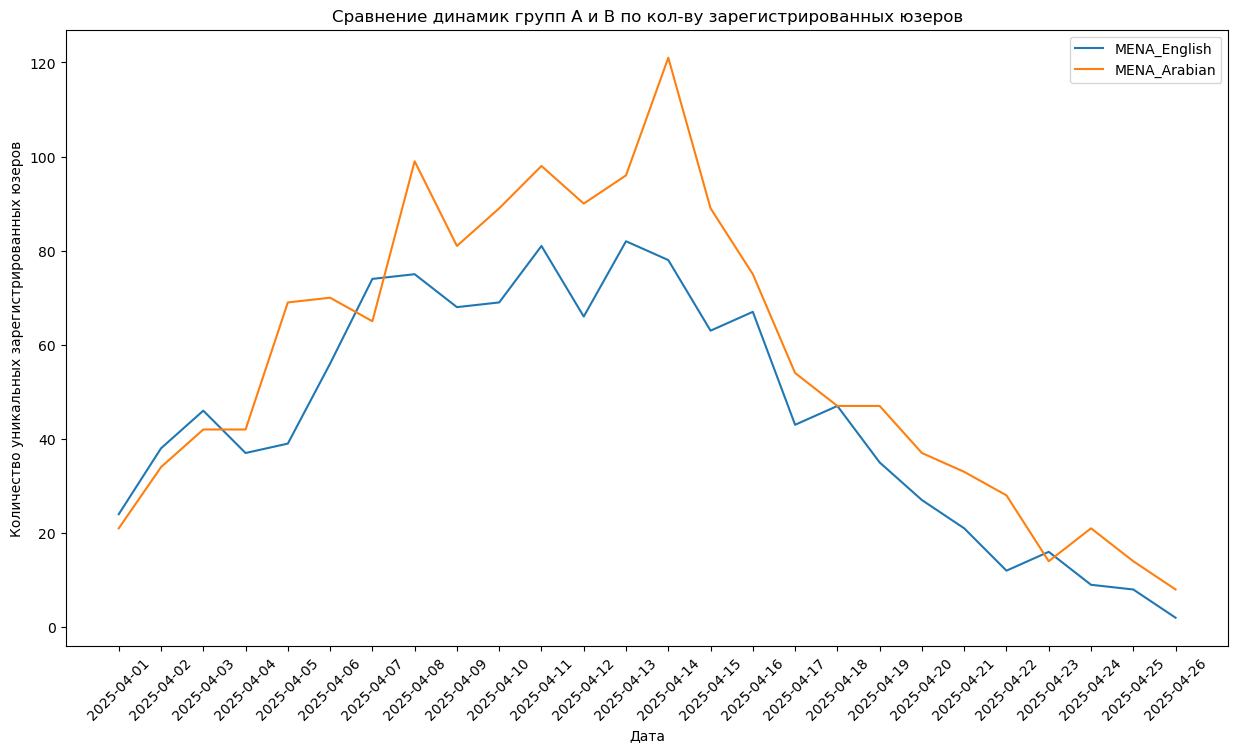

In [36]:
# Пример из урока
import pandas as pd
import matplotlib.pyplot as plt

# Выгружаем данные в датафрейм
df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')

df_exp = df[
    (
        df.registration_flag==1
    )&(
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]
df_grp = (
    df_exp
    .groupby(['test_group', 'session_date'])
    .agg({
        'user_id': 'nunique'
    })
    .reset_index()
)

x = df_grp[(df_grp.session_date<'2025-04-27')].session_date.unique()
y_a = df_grp[(df_grp.test_group=='MENA_English')&(df_grp.session_date<'2025-04-27')].user_id
y_b = df_grp[(df_grp.test_group=='MENA_Arabian')&(df_grp.session_date<'2025-04-27')].user_id

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='MENA_English')
plt.plot(x, y_b,label ='MENA_Arabian')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных зарегистрированных юзеров")
plt.xticks(rotation=45)
plt.legend()
plt.title('Сравнение динамик групп A и B по кол-ву зарегистрированных юзеров')
plt.show()

In [37]:
# The correct solution of task 2
import pandas as pd
from scipy.stats import mannwhitneyu

# Выгружаем данные в датафрейм
df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )
]

df_exp['hour_session_start'] = pd.to_datetime(df_exp['session_start_ts']).dt.hour

# Сформируйте целевую метрику для группы A 
metric_a = df_exp[
    (
        df_exp.test_group == 'MENA_English'
    )&(
        df_exp.device == 'Android'
    )&(
        df_exp.registration_flag == 0
    )
]['hour_session_start']
# Сформируйте целевую метрику для группы B
metric_b = df_exp[ 
    (
        df_exp.test_group == 'MENA_Arabian'
    )&(
        df_exp.device == 'Android'
    )&(
        df_exp.registration_flag == 0
    )
]['hour_session_start']

# Зафиксируйте уровень значимости
alpha = 0.1

# Проведите тест Манна — Уитни
stat_mw, p_value_mw = mannwhitneyu(
	metric_a,
	metric_b,
	alternative='two-sided'
)

# Выведите полученное p-value 
print(f'pvalue={p_value_mw}') 

if p_value_mw>alpha: # Напишите условие, на основе которого выбирается наиболее вероятная гипотеза
    print('Нулевая гипотеза находит подтверждение!')
    text_interpretation = 'не изменилось' # Напишите одно из выражений: "изменилось", "не изменилось"
else:
    print('Нулевая гипотеза не находит подтверждения!')
    text_interpretation = 'изменилось' # Напишите одно из выражений: "изменилось", "не изменилось"



print(f'При переводе интерфейса маркетплейса на арабский язык распределение часа старта сессии у незарегистрированных пользователей с устройствами на Android {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\2226546333.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv')


pvalue=0.3042828247961544
Нулевая гипотеза находит подтверждение!
При переводе интерфейса маркетплейса на арабский язык распределение часа старта сессии у незарегистрированных пользователей с устройствами на Android не изменилось


C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\2226546333.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp['hour_session_start'] = pd.to_datetime(df_exp['session_start_ts']).dt.hour


Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 5/10: Проверка результатов A/B-теста. Тест Манна-Уитни. Z-тест пропорций → Урок 4/4: Z-тест пропорций]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/612a56cf-f700-4203-9fce-92f5a50595b3/lessons/609ec7de-0547-4e89-be79-bd14ae6d0ae3/#1e8a7b1a-745a-4cb8-8c67-45e30ed8334a )
Вопрос: 

In [ ]:
# Интересный пример, когда можно создать новое поле в датафрейме и присвоить ему все значения в зависимости от другого поля
import pandas as pd

df = pd.read_csv('data_course_results.csv')

df['has_excellent'] = 0 # Здесь будет бинарная переменная, которая =0, когда студент не сдал на отлично, и =1 иначе
df.loc[df['Оценка'] == 5, 'has_excellent'] = 1 # Бинарная переменная для студентов, сдавших на 5

Ссылка на урок: [Спринт 13/15: Анализ результатов А/В тестирования с помощью Python → Тема 5/10: Проверка результатов A/B-теста. Тест Манна-Уитни. Z-тест пропорций → Урок 4/4: Z-тест пропорций]( https://practicum.yandex.ru/learn/data-analyst/courses/34e5b8e7-66ea-4d58-b962-eb39b27ff0c5/sprints/778849/topics/612a56cf-f700-4203-9fce-92f5a50595b3/lessons/609ec7de-0547-4e89-be79-bd14ae6d0ae3/#686d7c19-827b-41dc-9319-a16a8e91110b )
Вопрос: 

In [38]:
# Excercize
import pandas as pd

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') ## загружаем данные в Pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )&(
        df.device.isin(['PC', 'Mac'])
    )
]

n_a, n_b = df_exp[df_exp.test_group=='MENA_English'].shape[0], df_exp[df_exp.test_group=='MENA_Arabian'].shape[0] ## размеры выборок A и B
m_a = df_exp[(df_exp.test_group=='MENA_English')&(df_exp.registration_flag==1)].shape[0] # количество успехов (регистраций) в группе A
m_b = df_exp[(df_exp.test_group=='MENA_Arabian')&(df_exp.registration_flag==1)].shape[0] # количество успехов (регистраций) в группе B

p_a, p_b = m_a/n_a, m_b/n_b # рассчитываем доли успехов для каждой группы: A и B

print(f'n_a={n_a}, n_b={n_b}')
# 5818 5650

print(f'm_a={m_a}, m_b={m_b}')
# 405 580

print(f'p_a={p_a}, p_b={p_b}')
# 0.07 0.103

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\3427516470.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') ## загружаем данные в Pandas


n_a=5818, n_b=5650
m_a=405, m_b=580
p_a=0.06961155036094878, p_b=0.10265486725663717
Предпосылка о достаточном количестве данных выполняется!


In [39]:
# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

n_a, n_b = 5818, 5650 # Берём предыдущие значения по размерам выборок A и B 
m_a, m_b = 405, 580 # Берём предыдущие значения по количеству успехов в выборках A и B 

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве вероятностей

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)
p_value_ztest
# 1.3630147762819648e-10

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=1.3630147762819648e-10 < 0.05
Нулевая гипотеза не находит подтверждения!


In [40]:
# Решение задачки 1
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )&(
        df.device=='Android' # Заполните самостоятельно
    )&(
        df.page_counter == 1# Заполните самостоятельно
    )
]

n_a = df_exp[ # Посчитайте размер группы A
    df_exp.test_group=='MENA_English'
].shape[0]

n_b = df_exp[ # Посчитайте размер группы B
    df_exp.test_group=='MENA_Arabian'
].shape[0]
#print(n_a, n_b)
m_a = df_exp[ # Посчитайте кол-во успехов в группе A
    (df_exp.test_group=='MENA_English')&(df_exp.registration_flag==1)
].shape[0]

m_b = df_exp[ # Посчитайте количество успехов в группе B
     (df_exp.test_group=='MENA_Arabian')&(df_exp.registration_flag==1)
].shape[0]
#print(m_a, m_b)
p_a, p_b = m_a/n_a, m_b/n_b # Посчитайте доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # Проверьте предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # Установите уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # Проведите Z-тест пропорций
    [m_a, m_b],
    [n_a, n_b],	
    alternative='larger'
)

print(f'pvalue={p_value_ztest}') # Выведите полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = 'не изменилось' # Напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")

print(f'При переводе интерфейса маркетплейса на арабский язык количество регистраций у Android-пользователей, которые просматривали не более 1 страницы в рамках сессии, {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\2264386937.py:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


Предпосылка о достаточном количестве данных выполняется!
pvalue=0.2816938459723767
Нулевая гипотеза находит подтверждение!
При переводе интерфейса маркетплейса на арабский язык количество регистраций у Android-пользователей, которые просматривали не более 1 страницы в рамках сессии, не изменилось


Ура! Вы успешно провели Z-тест пропорций и доказали, что Android-пользователи, которые просматривали не более одной страницы за сессию (то есть менее активные пользователи), не стали реже регистрироваться после перевода интерфейса маркетплейса на арабский язык.

Задание 2 из 2
В результате предварительных исследований пользователей маркетплейса была выдвинута гипотеза: пользователи Mac, которые просматривают не более двух страниц за сессию, будут реже регистрироваться, если их интерфейс переведён на арабский язык.
Обозначим 
{
p
A
,
p
B
}
{p 
A
​
 ,p 
B
​
 } как доли зарегистрированных пользователей Mac, которые просматривают не более двух страниц за сессию. Гипотезы для теста будут выглядеть так:
Нулевая гипотеза 
H
0
H 
0
​
 : доля зарегистрированных пользователей Mac, которые просматривают не более двух страниц за сессию, не отличается между версией маркетплейса на английском и арабском языках — 
p
A
=
p
B
p 
A
​
 =p 
B
​
 .
Альтернативная гипотеза 
H
1
H 
1
​
 : доля зарегистрированных пользователей Mac, которые просматривают не более двух страниц за сессию, выше в версии маркетплейса на английском языке по сравнению с версией на арабском — 
p
A
>
p
B
p 
A
​
 >p 
B
​
 .
Уровень значимости равен 5%.
Проверьте эту продуктовую гипотезу на данных.

In [41]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas

df_exp = df[
    (
        df.session_date>='2025-04-01'
    )&(
        df.session_date<'2025-04-28'
    )&(
        df.test_name=='language_test'
    )&(
        df.device=='Mac' # Заполните самостоятельно
    )&(
        df.page_counter < 3# Заполните самостоятельно
    )
]

n_a = df_exp[ # Посчитайте размер группы A
    df_exp.test_group=='MENA_English'
].shape[0]

n_b = df_exp[ # Посчитайте размер группы B
    df_exp.test_group=='MENA_Arabian'
].shape[0]
#print(n_a, n_b)
m_a = df_exp[ # Посчитайте кол-во успехов в группе A
    (df_exp.test_group=='MENA_English')&(df_exp.registration_flag==1)
].shape[0]

m_b = df_exp[ # Посчитайте количество успехов в группе B
     (df_exp.test_group=='MENA_Arabian')&(df_exp.registration_flag==1)
].shape[0]
#print(m_a, m_b)
p_a, p_b = m_a/n_a, m_b/n_b # Посчитайте доли успехов для каждой группы: A и B

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # Проверьте предпосылку о достаточном количестве данных
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

alpha = 0.05 # Установите уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # Проведите Z-тест пропорций
    [m_a, m_b],
    [n_a, n_b],	
    alternative='larger'
)

print(f'pvalue={p_value_ztest}') # Выведите полученное p-value 

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

text_interpretation = 'не изменилось' # Напишите одно из выражений ("сократилось", "не изменилось", "увеличилось")

print(f'При переводе интерфейса маркетплейса на арабский язык количество регистраций у пользователей Mac, которые просматривали не более двух страниц в рамках сессии, {text_interpretation}')

C:\Users\Sergey\AppData\Local\Temp\ipykernel_15384\638318974.py:4: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://code.s3.yandex.net/datasets/experiment_data.csv') # Загружаем данные в pandas


Предпосылка о достаточном количестве данных выполняется!
pvalue=0.9906905381148304
Нулевая гипотеза находит подтверждение!
При переводе интерфейса маркетплейса на арабский язык количество регистраций у пользователей Mac, которые просматривали не более двух страниц в рамках сессии, не изменилось


Итак, вы успешно доказали, что пользователи Mac, которые просматривали не более двух страниц за сессию, не стали реже регистрироваться после перевода интерфейса маркетплейса на арабский язык.